The notebook generates simulated data using our data-generating process and compares the performance of different models.

In [15]:
import os
import sys

sys.path.insert(0, os.path.dirname(os.getcwd()))

In [16]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from causal_tree.causal_residual_tree import CausalResidualForest
from causal_tree.calibration import LinearEffectCalibration
from econml.grf import CausalForest

from simulation.data_generation import DataGenerator
from metrics import get_num_bins
from metrics import get_mse, rate_with_effect, expected_policy_effect, targted_ate_with_effect

random.seed(42)
np.random.seed(42)

In [17]:
# Configure the data generator.
n_features = 20
dg = DataGenerator(
    n_features=n_features, 
    y0_mean=0,
    ate=0.1,
    var_cay0=1,
    var_ratio=0.1,
    rho=0.5,
    var_noise=1.6,
    feature_map='identity',
    nonlinearity=None,
)
dg.reset_coef()

The base score is conditional baseline outcome, i.e. $\mathbb{E}[Y^0|X]$.

In [18]:
# Check data distribution.

data = dg.generate_data(n=50000)
bs = data['bs'].values      
cate = data['cate'].values
t = data['t'].values
y = data['y'].values
ate = y[t==1].mean() - y[t==0].mean()

print(f"Average treatment effect = {ate:.3f}")
print(f"Correlation between base scores and CATE = {np.corrcoef(bs, cate)[0][1]:.3f}")

Average treatment effect = 0.089
Correlation between base scores and CATE = 0.500


## Model comparison.

We compare the following models: 
* Base scores (BS). 
* Causal forest excluding base scores (CM).
* Monotonic calibration (P-CAL).
* Causal residual forest (P-RES).
* Causal forest with base scores (P-COV). 

In [19]:
def evaluate(effect, predictions, treated_thresh=0):

    mse = get_mse(effect, predictions)
    autoc, qini = rate_with_effect(effect, predictions, n_bins=100)

    decisions = 1 * (predictions>treated_thresh)
    epe = expected_policy_effect(effect, decisions)

    print(f"MSE = {mse:.5f}, AUTOC = {autoc:.5f}, Qini = {qini:.5f}, EPG = {epe:.5f}")


In [20]:
# Generate training and test set.
dg.reset_coef()
train_size = 1024
train = dg.generate_data(n=train_size)
X_tr = train.iloc[:, :n_features].values
bs_tr = train['bs'].values
Xb_tr = np.c_[X_tr, bs_tr]
t_tr = train['t'].values
y_tr = train['y'].values


test = dg.generate_data(n=50000)
X_te = test.iloc[:, :n_features].values
bs_te = test['bs'].values
Xb_te = np.c_[X_te, bs_te]
t_te = test['t'].values
y_te = test['y'].values
cate_te = test['cate'].values



In [21]:
# The true CATE is evaluated to establish a theoretical upper bound on model performance.
evaluate(cate_te, cate_te)

MSE = 0.00000, AUTOC = 0.28013, Qini = 0.08960, EPG = 0.18338


In [22]:
# Base scores
evaluate(cate_te, bs_te)

MSE = 0.79377, AUTOC = 0.14055, Qini = 0.04452, EPG = 0.11277


In [23]:
# Causal forest excluding base scores

cf = CausalForest(n_estimators=100, criterion='het', min_samples_leaf=0.1, honest=False)
cf.fit(X_tr, t_tr, y_tr)
pred_cm = np.squeeze(cf.predict(X_te))
evaluate(cate_te, pred_cm)

MSE = 0.12150, AUTOC = 0.06249, Qini = 0.02239, EPG = 0.09077


In [24]:
# Monotonic calibration

n_bins = get_num_bins(train_size)
cal = LinearEffectCalibration(n_bins=n_bins)
cal.fit(bs_tr, t_tr, y_tr)
cbs_tr = cal.predict(bs_tr)
pred_cal = cal.predict(bs_te)
evaluate(cate_te, pred_cal)

MSE = 0.07778, AUTOC = 0.14055, Qini = 0.04452, EPG = 0.12502


In [25]:
# Causal forest with base scores

cf_bs = CausalForest(n_estimators=100, criterion='het', min_samples_leaf=100, honest=False)
cf_bs.fit(Xb_tr, t_tr, y_tr)
pred_cov = np.squeeze(cf_bs.predict(Xb_te))
evaluate(cate_te, pred_cov)

MSE = 0.08710, AUTOC = 0.10808, Qini = 0.03526, EPG = 0.11218


In [26]:
# Causal residual forest 

crf = CausalResidualForest(n_estimators=100, min_samples_leaf=0.1)
crf.fit(X_tr, t_tr, y_tr, cbs_tr)
pred_res = pred_cal + crf.predict(X_te)
evaluate(cate_te, pred_res)

MSE = 0.07270, AUTOC = 0.14246, Qini = 0.04734, EPG = 0.12952


In [27]:
def plot_uplift_curves(eff, score_dict, n_bins=100, ax=None):
    """
    x-axis is targeted proportion. 
    y-axis is increment in outcomes (considering targeted size).
    """

    if ax is None:
        fig, ax = plt.subplots()

    n = eff.shape[0]
    eff = np.array(eff)
    ate = eff.mean()
    ax.plot([0, 1], [0, ate*n], label='Random')

    for label, scores in score_dict.items():
        targeted_prop, targeted_ate = targted_ate_with_effect(eff, scores, n_bins)
        targeted_uplift = targeted_ate * targeted_prop * n
        targeted_prop = np.r_[0, targeted_prop]
        targeted_uplift = np.r_[0, targeted_uplift]

        ax.plot(targeted_prop, targeted_uplift, label=label)

    ax.set_xlabel('Targeted proportion')
    ax.set_ylabel("Increment in Outcome")
    ax.legend()

Increment in Y for varied targeted proportion.
We excluded Calibration here as it has the same ranking as the Base score.

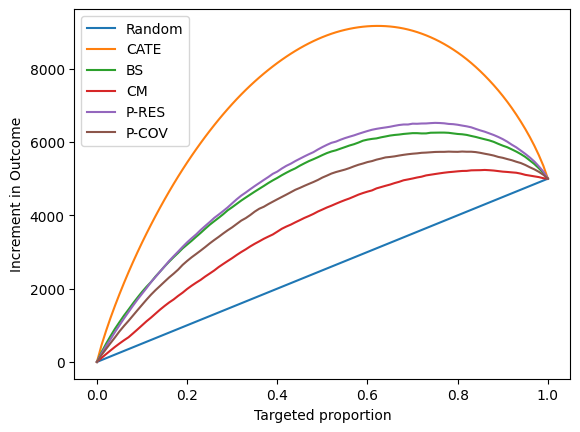

In [28]:
score_dict = {
    'CATE': cate_te,
    'BS': bs_te,
    'CM': pred_cm,
    'P-RES': pred_res,
    'P-COV': pred_cov
}

plot_uplift_curves(cate_te, score_dict, n_bins=100, ax=None)